# 02 — How a row was written, and what that decides about the clocks

Notebook 01 read the columns. This one asks what wrote them, because two of them are
timestamps and the serving path lives or dies on what they mean: is `created_at` when the
user left, or when a job wrote the row? Does `minutes_since_abandonment` keep ticking
afterwards? Should either be a feature?

Only the reading that survives every piece of evidence is written down — the alternatives
the data rules out are not worth the page.

In [1]:
%matplotlib inline
import sys
sys.path.insert(0, ".")
from pe_style import *
from priority_engine import db, features
from priority_engine.config import CFG

df = leads_db()                                  # deduplicated: one row per lead_id
raw = sql("SELECT * FROM pe.leads")              # pre-dedupe, for section 2
Y = "completed_purchase"
M = "minutes_since_abandonment"
SUPPORT = CFG["priority"]["decay_support_minutes"]

print(f"curated {len(df):,} rows   raw {len(raw):,} rows   "
      f"ingested_at distinct: {raw['ingested_at'].nunique()}")
print(f"span    {df['created_at'].min():%Y-%m-%d %H:%M} → {df['created_at'].max():%Y-%m-%d %H:%M}")

curated 50,000 rows   raw 50,180 rows   ingested_at distinct: 1
span    2026-04-01 00:19 → 2026-08-28 23:58


## 1. `created_at` is a write stamp, not the moment anything happened

Four properties, none of which human traffic has.

seconds always 00      100.0%
minute-of-hour values  60 of 60 used
hour-of-day spread     CV 2.7%
day-of-week spread     CV 2.4%
rows per calendar day  333 over 150 days, CV 5.4%
corr(created_at, minutes_since_abandonment)  +0.0008

implied abandonment hour CV 2.7%  — flat too, so subtracting the age does not recover an event time either


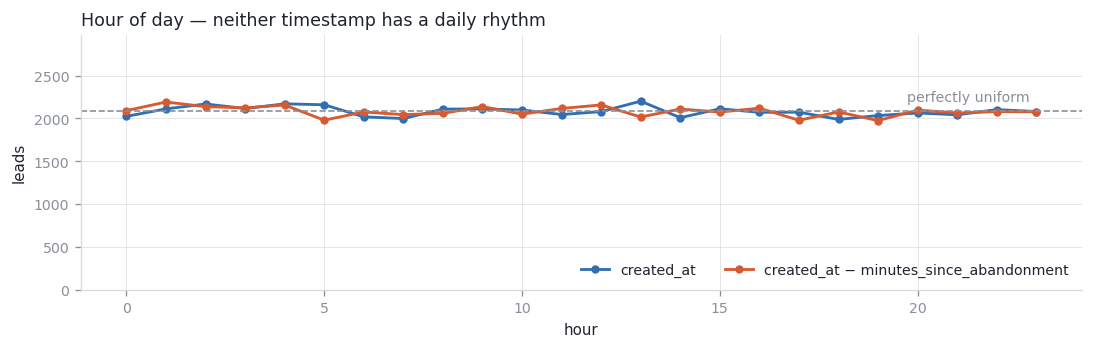

In [2]:
ca = df["created_at"]
hours = ca.dt.hour.value_counts().sort_index()
days = ca.dt.floor("D").value_counts()
dow = ca.dt.dayofweek.value_counts()

print(f"seconds always 00      {(ca.dt.second == 0).mean():.1%}")
print(f"minute-of-hour values  {ca.dt.minute.nunique()} of 60 used")
print(f"hour-of-day spread     CV {100 * hours.std() / hours.mean():.1f}%")
print(f"day-of-week spread     CV {100 * dow.std() / dow.mean():.1f}%")
print(f"rows per calendar day  {days.mean():.0f} over {len(days)} days, CV {100 * days.std() / days.mean():.1f}%")
print(f"corr(created_at, {M})  {np.corrcoef(df[M], ca.astype('int64'))[0, 1]:+.4f}")

# If created_at were a real event time, subtracting the lead's age would give the
# abandonment moment -- and *that* would carry the diurnal shape instead.
implied = ca - pd.to_timedelta(df[M], unit="m")
ih = implied.dt.hour.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9.2, 3.0))
ax.plot(hours.index, hours.values, "o-", color=BLUE, lw=1.7, ms=4, label="created_at")
ax.plot(ih.index, ih.values, "o-", color=CORAL, lw=1.7, ms=4,
        label=f"created_at − {M}")
ax.axhline(len(df) / 24, ls="--", lw=1, color=MUTED)
ax.annotate("perfectly uniform", (23, len(df) / 24), xytext=(-4, 6),
            textcoords="offset points", ha="right", fontsize=8.5, color=MUTED)
ax.set_ylim(0, hours.max() * 1.35)
ax.set_title("Hour of day — neither timestamp has a daily rhythm")
ax.set_xlabel("hour"); ax.set_ylabel("leads"); ax.legend(loc="lower right", ncol=2)
save(fig, "02_clocks")

print(f"\nimplied abandonment hour CV {100 * ih.std() / ih.mean():.1f}%  "
      "— flat too, so subtracting the age does not recover an event time either")

Seconds are always `00`, every minute-of-hour is used, hour-of-day and weekday are flat to
~3% (real consumer traffic never is), the daily count is near-constant at ~333, and the
column correlates with the lead's age at +0.001.

The second line on the chart is the test that matters: if `created_at` were the
abandonment moment, `created_at − minutes_since_abandonment` would be a derived time and
one of the two would look human. **Neither does — whatever wrote these rows ran on a
schedule.**

## 2. The 180 duplicate `lead_id`s say what the age column does *not* do

Notebook 01 found 180 duplicated ids and the curated view keeps the newest. That looked
like tidy-up. It is also the only place the same lead is observed twice.

In [3]:
dup = raw[raw.duplicated("lead_id", keep=False)].sort_values(["lead_id", "created_at"])
varies = {}
for _, g in dup.groupby("lead_id"):
    n = g.drop(columns=["id", "ingested_at"]).nunique()
    for c in n[n > 1].index:
        varies[c] = varies.get(c, 0) + 1

gaps = dup.groupby("lead_id")["created_at"].agg(lambda s: (s.max() - s.min()).total_seconds() / 60)

print(f"{dup['lead_id'].nunique()} lead_ids appear twice")
print(f"columns that differ inside a pair: {varies}")
print(f"write-stamp gap: min {gaps.min():.0f} min, median {gaps.median():.0f}, max {gaps.max():.0f}")
print(f"pairs whose {M} is identical across the gap: "
      f"{int(dup.groupby('lead_id')[M].nunique().eq(1).sum())} of {dup['lead_id'].nunique()}\n")
print(dup.head(4)[["lead_id", "created_at", M, Y]].to_string(index=False))

180 lead_ids appear twice
columns that differ inside a pair: {'created_at': 180}
write-stamp gap: min 1 min, median 8, max 14
pairs whose minutes_since_abandonment is identical across the gap: 180 of 180

lead_id                created_at  minutes_since_abandonment  completed_purchase
L100058 2026-08-01 17:03:00+00:00                        155                   0
L100058 2026-08-01 17:10:00+00:00                        155                   0
L100078 2026-07-25 19:18:00+00:00                         47                   0
L100078 2026-07-25 19:30:00+00:00                         47                   0


Every pair differs in `created_at` and nothing else. The stamps sit 1–14 minutes apart,
and across that gap the age column does **not** move — not in one pair.

**So `minutes_since_abandonment` is frozen at capture and copied onto each write.** That
cuts both ways: it confirms the write-stamp reading, and it means the file contains no
observation of a lead ageing. Every row is one lead at one age.

## 3. The age is censored at six hours, and it carries real signal

Two questions: how far does the column go, and is it worth anything.

minutes_since_abandonment: min 1  median 83  max 360  integers only: True
330–359 holds 141 leads (≈4.7/min); exactly 360 holds 146 — 31× the local rate



                               n  rate %
minutes_since_abandonment               
(0, 60]                    16507   11.27
(60, 120]                  19334    9.30
(120, 180]                  9201    7.23
(180, 240]                  3385    5.73
(240, 300]                  1080    4.26
(300, 359]                   347    4.90
(359, 360]                   146    2.74

fitted decline 0.793× per hour   (config priority.decay_per_hour = 0.778)


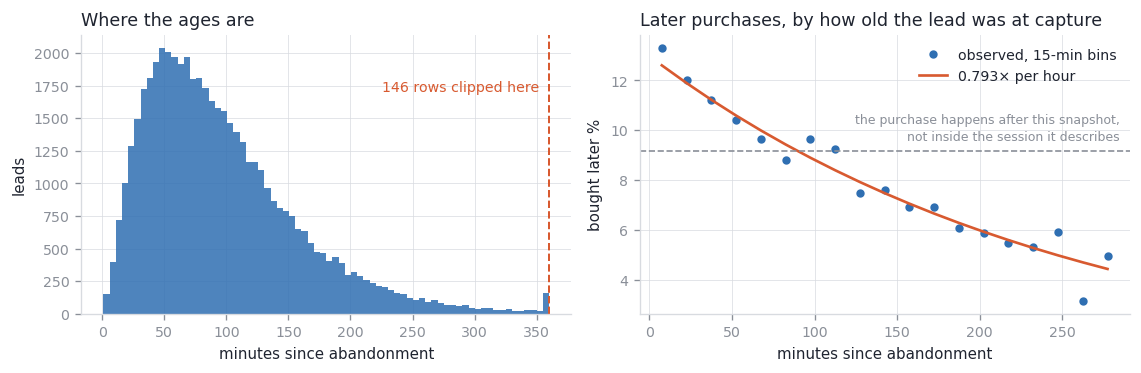

In [4]:
print(f"{M}: min {df[M].min():.0f}  median {df[M].median():.0f}  max {df[M].max():.0f}  "
      f"integers only: {np.allclose(df[M], df[M].round())}")
local = df[M].between(330, 359).sum() / 30
print(f"330–359 holds {df[M].between(330, 359).sum()} leads (≈{local:.1f}/min); "
      f"exactly 360 holds {int((df[M] == 360).sum())} — {(df[M] == 360).sum() / local:.0f}× the local rate\n")

buckets = pd.cut(df[M], [0, 60, 120, 180, 240, 300, 359, 360], right=True)
t = df.groupby(buckets, observed=True)[Y].agg(n="count", rate="mean")

# A log-linear fit on 15-minute bins is the cross-sectional decay: what a *colder*
# lead converts at, not what happens to a lead as it cools. Section 6 keeps that apart.
g = df.groupby(pd.cut(df[M], np.arange(0, 361, 15), right=False), observed=True)[Y].agg(n="count", rate="mean")
g = g[(g["n"] > 200) & (g["rate"] > 0)]
x = np.array([i.left + 7.5 for i in g.index])
slope = np.polyfit(x, np.log(g["rate"]), 1, w=np.sqrt(g["n"]))[0]

fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.2))
axes[0].hist(df[M], bins=72, color=BLUE, alpha=0.85)
axes[0].axvline(SUPPORT, ls="--", lw=1.2, color=CORAL)
axes[0].annotate(f"{int((df[M] == 360).sum())} rows clipped here",
                 (SUPPORT, axes[0].get_ylim()[1] * 0.8), xytext=(-6, 0),
                 textcoords="offset points", ha="right", fontsize=8.5, color=CORAL)
axes[0].set_title("Where the ages are"); axes[0].set_xlabel("minutes since abandonment")
axes[0].set_ylabel("leads")

axes[1].plot(x, g["rate"] * 100, "o", color=BLUE, ms=4, label="observed, 15-min bins")
axes[1].plot(x, np.exp(np.polyval(np.polyfit(x, np.log(g["rate"]), 1, w=np.sqrt(g["n"])), x)) * 100,
             color=CORAL, lw=1.6, label=f"{np.exp(slope * 60):.3f}× per hour")
axes[1].axhline(df[Y].mean() * 100, ls="--", lw=1, color=MUTED)
axes[1].set_title("Later purchases, by how old the lead was at capture")
axes[1].set_xlabel("minutes since abandonment")
axes[1].set_ylabel("bought later %"); axes[1].legend()
axes[1].annotate("the purchase happens after this snapshot,\nnot inside the session it describes",
                 (0.98, 0.72), xycoords="axes fraction", ha="right", va="top",
                 fontsize=7.5, color=MUTED, linespacing=1.4)
save(fig, "02_age_curve")

t["rate %"] = (t["rate"] * 100).round(2)
print(t[["n", "rate %"]].to_string())
print(f"\nfitted decline {np.exp(slope * 60):.3f}× per hour   "
      f"(config priority.decay_per_hour = {CFG['priority']['decay_per_hour']})")

The column never reads 0, never exceeds 360, and minute 360 holds ~31× the density below
it — **a clip, not the end of a range.** Past six hours the model has no evidence.

Inside them the signal is real and monotone: 11.3% in the first hour down to 4–5% in the
sixth, a smooth 0.793× per hour on the rate scale. The clipped rows convert at 2.7%, which
is what a mixture of much older leads should look like.

The next cell fits the same decline on the **odds** scale and gets 0.778× — which is where
`priority.decay_per_hour` comes from. The odds version is what the serving path needs,
because it multiplies a probability.

In [5]:
# Is the decline the ages, or the kind of lead that tends to be old? Ask the same
# question with every other feature held alongside it.
X = features.build(df).drop(columns=["expiry_x_abandonment"])   # drop the age interaction
D = pd.get_dummies(X, columns=features.CATEGORICAL, drop_first=True).astype(float)
D = D.fillna(D.median())
y = df[Y].to_numpy(int)

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

def per_hour(cols):
    Z = D[cols].to_numpy()
    sc = StandardScaler().fit(Z)
    fit = LogisticRegression(max_iter=2000, C=1e6).fit(sc.transform(Z), y)
    beta = fit.coef_[0][cols.index(M)] / sc.scale_[cols.index(M)]
    return np.exp(beta * 60)

print(f"age alone                       {per_hour([M]):.3f}× odds per hour")
print(f"age + every other feature       {per_hour(list(D.columns)):.3f}× odds per hour\n")

for c in ["visited_offer_page", "has_previous_purchase", "incoming_call_last_24h",
          "sessions_last_7d", "offer_views_last_7d", "price"]:
    v = pd.to_numeric(df[c], errors="coerce")
    print(f"corr({c:<24}, age) {np.corrcoef(v.fillna(v.mean()), df[M])[0, 1]:+.4f}")

age alone                       0.778× odds per hour
age + every other feature       0.770× odds per hour

corr(visited_offer_page      , age) -0.0439
corr(has_previous_purchase   , age) +0.0106
corr(incoming_call_last_24h  , age) +0.0641
corr(sessions_last_7d        , age) -0.0058
corr(offer_views_last_7d     , age) -0.0188
corr(price                   , age) -0.0012


Controlling for every other feature moves the age effect from 0.778× to 0.770× per hour,
and nothing correlates with age past ±0.07. **The decline is not "older leads are worse
leads"**, as far as this file can see.

What it cannot rule out is survivor composition on the unobservable: keen buyers leave the
population by buying. One snapshot per lead (§2) makes that indistinguishable from a lead
cooling — which is why the serving decay is treated as an **upper bound**.

## 4. The assumption that survives

> **A `lead` row is a snapshot of a priced quote, written by a scheduled job.**
> `created_at` is when the job wrote it; `minutes_since_abandonment` is the lead's age when
> it was captured, right-censored at six hours; `completed_purchase` was backfilled after.
> One row is one lead at one age, and the file never shows the same lead at two ages.

**And the label is a later purchase, not this session's.** Notebook 01 found 517 buyers who
never reached the offer page at all — they bought through a channel this row does not
describe. So `completed_purchase = 1` means "bought at some point after the snapshot", and
the queue is ranking who will buy next rather than who was about to click. That is also
why the label had to be backfilled, and why the training set excludes anything newer than
the attribution window.

The data is synthetic, and flat clocks with independent columns are what independent draws
look like — so there may be no "true" process to recover. It is still worth stating,
because everything below rests on it and each line is a one-line change if it is wrong.

## 5. What a lead's age is at inference

```
age_now = LEAST(minutes_since_abandonment + (now − created_at), 360)
```

That is `predict.leads_needing_score`, and it is why the queue needs no event stream: the
two columns together reconstruct a clock neither carries alone.

In [6]:
# What that expression does to this dataset, read at the dataset's own clock.
now = df["created_at"].max()
age_now = df[M] + (now - df["created_at"]).dt.total_seconds() / 60
horizon = CFG["priority"]["queue_horizon_hours"] * 60

print(f"clock = {db.clock_mode()}   now = {now:%Y-%m-%d %H:%M}\n")
print(f"inside the {SUPPORT}-min support   {(age_now <= SUPPORT).sum():>6,} leads  "
      f"({(age_now <= SUPPORT).mean():.2%})  — re-inferred by the 5-min job")
print(f"past support, inside {CFG['priority']['queue_horizon_hours']}h horizon "
      f"{((age_now > SUPPORT) & (age_now <= horizon)).sum():>6,} leads  "
      f"({((age_now > SUPPORT) & (age_now <= horizon)).mean():.2%})  — anchored, decayed at read time")
print(f"past the horizon                 {(age_now > horizon).sum():>6,} leads  "
      f"({(age_now > horizon).mean():.2%})  — out of the queue entirely")
print(f"\nwall-clock would put the median lead at {(pd.Timestamp.now(tz='UTC') - df['created_at']).dt.days.median():.0f} "
      "days old, which is why priority.current_time pins it to the dataset here")

clock = dataset   now = 2026-08-28 23:58

inside the 360-min support       48 leads  (0.10%)  — re-inferred by the 5-min job
past support, inside 24h horizon    260 leads  (0.52%)  — anchored, decayed at read time
past the horizon                 49,692 leads  (99.38%)  — out of the queue entirely

wall-clock would put the median lead at 89 days old, which is why priority.current_time pins it to the dataset here


| Decision | Why |
|---|---|
| `minutes_since_abandonment` **is** a feature | monotone 11.3% → 4.9% over six hours, and it survives controlling for every other column (0.778× → 0.770×/h) |
| `created_at` is **not** a feature | a scheduling artefact — flat by hour and weekday, +0.001 with the age column. Feeding it in fits the export job |
| age = `minutes + (now − created_at)`, capped at 360 | the only reading the assumption allows; past the cap the model would be inventing |
| re-infer inside the support, decay outside | inside, the model saw leads of that age; outside, every training row was censored to the boundary |
| the decay is a **ranking device**, not a probability | fitted across leads, and §2 shows the file never watches one lead age — so it is an upper bound |
| decay only the time **past** the boundary | the model already priced the age it was handed |
| leads leave the queue at the horizon | a constant fitted on six hours cannot be extrapolated across days (notebook 04 sets it at 24h) |
| both clocks advance together (`advance_clock`) | moving one and not the other invents a lead that aged while the calendar stood still |
| dedupe on `lead_id`, keep the newest write | pairs differ only in the stamp, and the newest is what makes `now − created_at` right |
| `priority.current_time` pins "now" | a fixed export read on a live clock puts every lead months past its support |
| newest 28 days held out | the label is a *later* purchase, so a fresh row's outcome is not final yet; 28 days absorbs any attribution window up to that length |